## Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import shap

c:\Users\59171\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load processed data and variables

In [3]:
results_df = pd.read_csv(
    "../data/processed/model_predictions.csv"
)

In [4]:
y_test = results_df["actual_default"]

log_pred_prob = results_df["log_pred_prob"]

lgbm_pred_prob = results_df["lgbm_pred_prob"]

X_test = results_df.drop(
    columns=[
        "actual_default",
        "log_pred_prob",
        "lgbm_pred_prob"
    ]
)

In [5]:
import joblib

log_reg_pipeline = joblib.load(
    "../models/log_reg_pipeline.pkl"
)

lgbm_pipeline = joblib.load(
    "../models/lgbm_pipeline.pkl"
)

## Calibration Analysis

In [ ]:
# logistic regression calibration curve
log_prob_true, log_prob_pred = calibration_curve(
    y_test,
    log_pred_prob,
    n_bins=10
)

In [ ]:
# LightGBM calibration curve
lgbm_prob_true, lgbm_prob_pred = calibration_curve(
    y_test,
    lgbm_pred_prob,
    n_bins=10
)

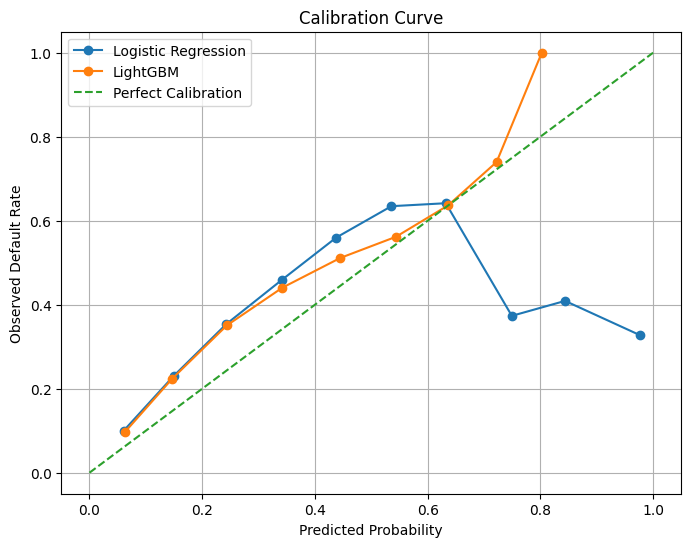

In [ ]:
# Plot Calibration Curves
plt.figure(figsize=(8,6))

plt.plot(
    log_prob_pred,
    log_prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    lgbm_prob_pred,
    lgbm_prob_true,
    marker="o",
    label="LightGBM"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")

plt.title("Calibration Curve")
plt.legend()

plt.grid(True)

plt.show()

***Interpretation***

The Logistic Regression model demonstrated relatively stable
calibration across probability buckets, while the LightGBM
model exhibited stronger nonlinear predictive power but mild
deviations from perfect calibration at higher predicted risk
levels.

Calibration quality is particularly important in lending
applications because underwriting, pricing, and reserve
decisions depend on reliable probability estimates.

## Threshold Analysis

In [ ]:
# Create Threashold loop
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for threshold in thresholds:

    pred_class = (
        lgbm_pred_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        pred_class
    )

    recall = recall_score(
        y_test,
        pred_class
    )

    approval_rate = (
        pred_class == 0
    ).mean()

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "approval_rate": approval_rate
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,approval_rate
0,0.1,0.314211,0.902879,0.258138
1,0.2,0.407811,0.575127,0.635901
2,0.3,0.486475,0.288513,0.846884
3,0.4,0.542667,0.144564,0.931224
4,0.5,0.584106,0.067013,0.970380


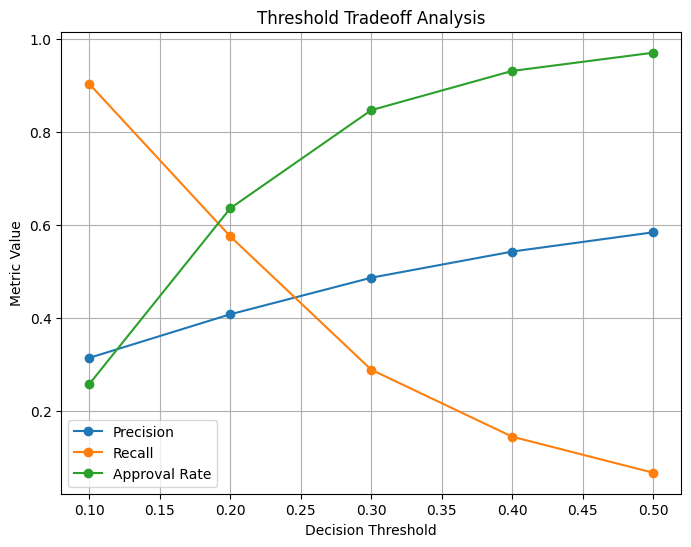

In [ ]:
# Plot Threshold Tradeoff
plt.figure(figsize=(8,6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["approval_rate"],
    marker="o",
    label="Approval Rate"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")

plt.title("Threshold Tradeoff Analysis")

plt.legend()

plt.grid(True)

plt.show()

Lower approval thresholds increased borrower approval rates
but also increased exposure to higher-risk applicants.

Higher thresholds improved precision by reducing approvals
to risky borrowers, but at the expense of rejecting more
potentially creditworthy applicants.

This illustrates the core underwriting tradeoff between
portfolio growth and credit quality.

## Confusion Matrix

In [ ]:
# Example threshold
threshold = 0.3

In [ ]:
# create predicted class based on threshold
pred_class = (
    lgbm_pred_prob >= threshold
).astype(int)

In [ ]:
# build confusion matrix
cm = confusion_matrix(
    y_test,
    pred_class
)

cm

array([[359792,  42657],
       [ 99653,  40410]])

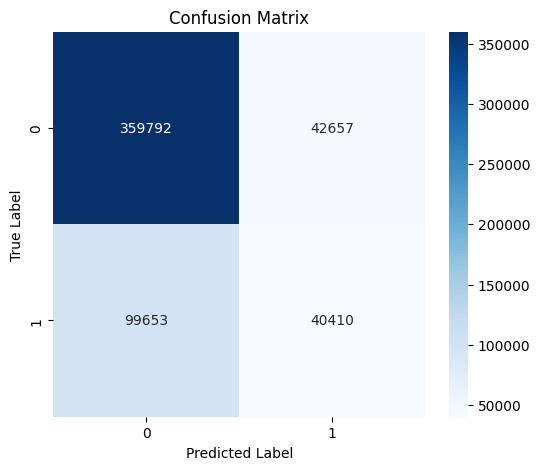

In [ ]:
# plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Classification Report
print(
    classification_report(
        y_test,
        pred_class
    )
)

              precision    recall  f1-score   support

           0       0.78      0.89      0.83    402449
           1       0.49      0.29      0.36    140063

    accuracy                           0.74    542512
   macro avg       0.63      0.59      0.60    542512
weighted avg       0.71      0.74      0.71    542512



***Interpretation***

False negatives represent risky borrowers incorrectly
classified as safe, creating potential credit losses.

False positives represent creditworthy borrowers rejected
by the underwriting model, reducing origination volume
and potential interest revenue.

Threshold selection therefore reflects business risk
tolerance rather than purely statistical optimization.

## Feature Importance

In [1]:
# extract LightGBM Model
model = lgbm_pipeline.named_steps["model"]

NameError: name 'lgbm_pipeline' is not defined

In [ ]:
# Extract Feature Names
feature_names = (
    lgbm_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [ ]:
# Build Importance Table
importance = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

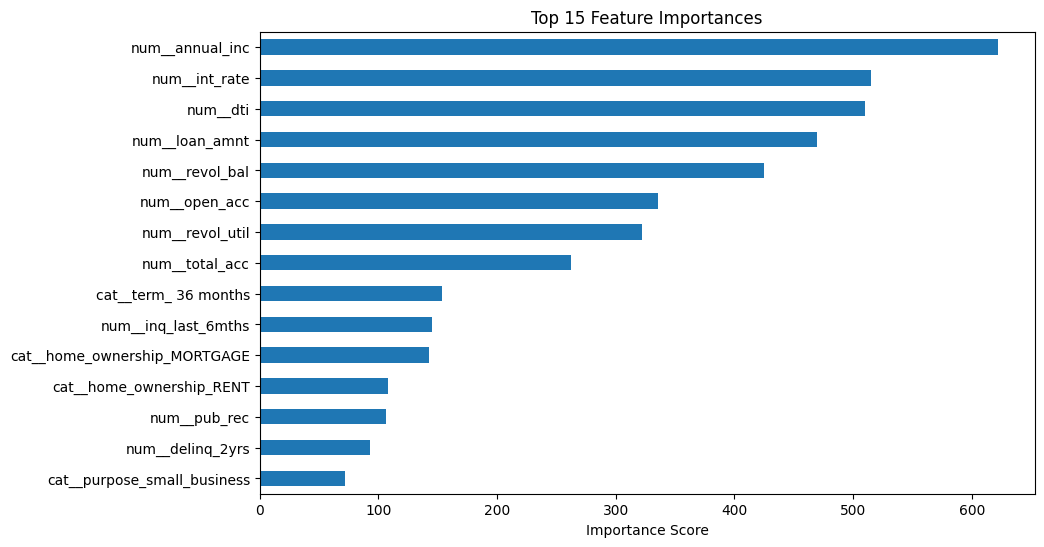

In [ ]:
# Plot Top Features
plt.figure(figsize=(10,6))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances")

plt.xlabel("Importance Score")

plt.show()

***Interpretation***

Variables related to borrower leverage, repayment burden,
and prior credit stress emerged as the strongest predictors
of default risk.

The importance rankings suggest that affordability and
credit-history quality remain central drivers of consumer
loan performance.

## SHAP Explainability

In [ ]:
# Preprocess Test Features
X_test_processed = (
    lgbm_pipeline.named_steps["preprocessor"]
    .transform(X_test)
)

In [ ]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(model)

In [ ]:
# Calculate SHAP Values
shap_values = explainer.shap_values(
    X_test_processed
)

c:\Users\59171\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


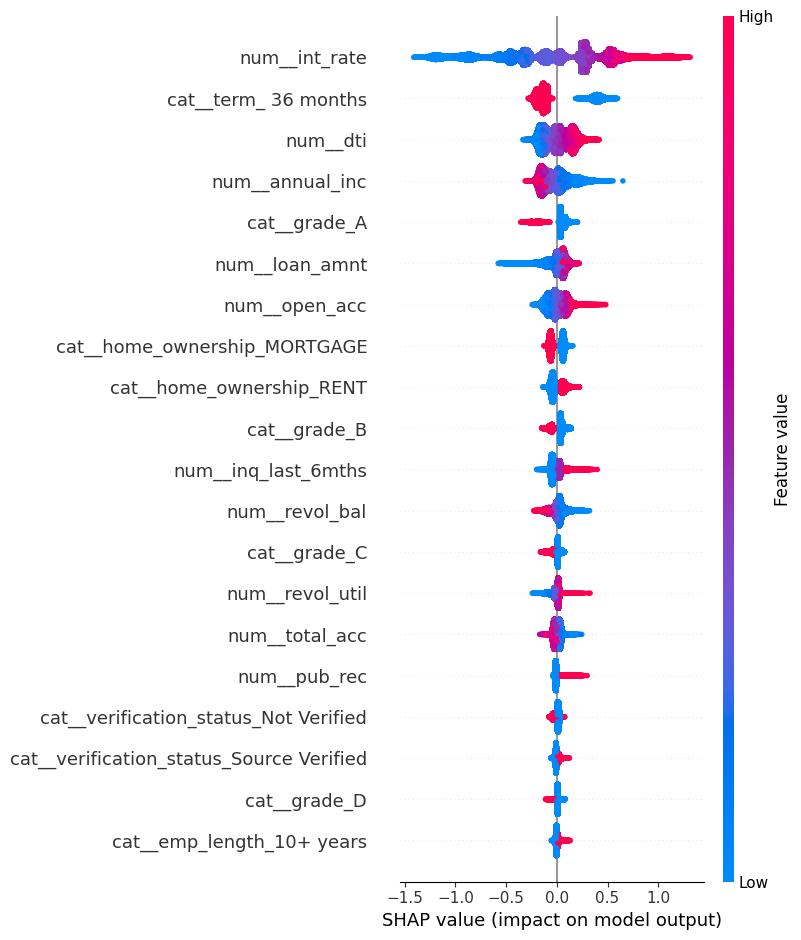

<Figure size 640x480 with 0 Axes>

In [ ]:
# SHAP summary Plot
import shap
shap.summary_plot(
    shap_values.toarray(),
    X_test_processed.toarray(),
    feature_names=feature_names
)

plt.tight_layout()
plt.savefig("../Visual/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

***Interpretation***

SHAP analysis showed that higher interest rates, elevated
debt-to-income ratios, weaker credit grades, and longer
loan durations consistently increased predicted default
risk.

These patterns aligned with intuitive underwriting
expectations and reinforced the model's business
interpretability.

## Portfolio Risk Segmentation

In [25]:
# Create Risk Bands
risk_band = pd.cut(
    lgbm_pred_prob,
    bins=[0, 0.05, 0.15, 0.30, 1],
    labels=[
        "Low",
        "Moderate",
        "Elevated",
        "High"
    ]
)

In [26]:
# Add to DataFrame
results_df = X_test.copy()

results_df["actual_default"] = y_test.values

results_df["predicted_pd"] = lgbm_pred_prob

results_df["risk_band"] = risk_band

In [27]:
# Analyze risk bands
segment_summary = (
    results_df.groupby("risk_band")
    .agg(
        borrower_count=("actual_default", "count"),
        actual_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("predicted_pd", "mean")
    )
)

segment_summary

,borrower_count,actual_default_rate,avg_predicted_pd
risk_band,,,
Low,46691,0.053179,0.035617
Moderate,205617,0.158683,0.102886
Elevated,207137,0.311591,0.212505
High,83067,0.486475,0.412750


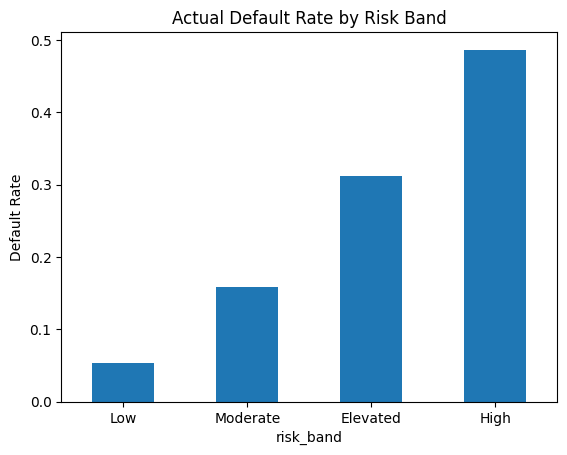

In [28]:
# Plot segment default rates
segment_summary["actual_default_rate"].plot(
    kind="bar"
)

plt.title("Actual Default Rate by Risk Band")

plt.ylabel("Default Rate")

plt.xticks(rotation=0)

plt.show()

***Interpretation***

The model successfully differentiated borrower populations
into progressively riskier segments, with observed default
rates increasing consistently across predicted risk bands.

This type of segmentation could support underwriting,
portfolio monitoring, and collections prioritization.

## Business Recommendations

1. Borrowers with elevated DTI ratios and longer loan
terms demonstrated materially higher default risk and
may warrant tighter underwriting review.

2. The LightGBM model provided stronger discriminatory
power than Logistic Regression, while Logistic Regression
offered greater interpretability and transparency.

3. Calibration analysis suggested that probability outputs
were reasonably aligned with observed default behavior,
supporting potential use in risk ranking and portfolio
monitoring applications.

4. Risk segmentation analysis identified concentrated
default exposure within higher predicted PD groups,
which could support enhanced monitoring and early
intervention strategies.

## Limitations

1. The LendingClub dataset reflects a specific lender and
may not generalize across all consumer lending portfolios.

2. The dataset only contains approved borrowers, creating
potential selection bias.

3. Macroeconomic conditions may shift over time, reducing
future model stability.

4. Additional borrower-level behavioral or transaction
data could improve predictive performance.